
# Patch Antenna AI — Colab Notebook (GNN Encoder + FEDformer Decoder)

Train a model that maps a **10×10 geometry** (100 bits) to complex **S11** across **61 frequency points**, evaluate it, and plot **loss vs. epoch**. Includes an optional **Gradio GUI**.


In [1]:

# 1) Setup & installs
!pip -q install gradio matplotlib pandas numpy


In [2]:
# 1a) Show environment info
import torch, pandas as pd, numpy as np, sys

print("Python version:", sys.version.split()[0])
print("PyTorch version:", torch.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


Python version: 3.12.12
PyTorch version: 2.8.0+cu126
Pandas version: 2.2.2
NumPy version: 2.0.2
CUDA available: False


In [3]:
# 2) Configuration
from dataclasses import dataclass
@dataclass
class Cfg:
    csv_path: str = "/content/Full_1000Data.csv"
    test_csv_path: str = "/content/Full_1000Data.csv"
    input_dim: int = 100
    seq_len: int = 61
    output_mode: str = "mag_only"
    batch_size: int = 64
    lr: float = 1e-3
    epochs: int = 50
    val_split: float = 0.2
    dmodel: int = 128
    nhead: int = 8
    ffn_hidden: int = 256
    num_transformer_layers: int = 2
    num_spectral_blocks: int = 2
    top_k_freq: int = 16
    freq_hz_start: float = 1e9
    freq_hz_stop: float = 6e9
    device: str = "auto"
    transformer_dropout: float = 0.3
    weight_decay: float = 1e-5

    # --- Data augmentation (training data only) ---
    aug_noise_std: float = 0.01        # standard deviation for noise injection
    aug_freq_mask_prob: float = 0.5    # probability of applying a freq mask per sample
    aug_freq_mask_width: int = 8       # max width (in freq bins) of the mask

CFG = Cfg(); CFG


Cfg(csv_path='/content/Full_1000Data.csv', test_csv_path='/content/Full_1000Data.csv', input_dim=100, seq_len=61, output_mode='mag_only', batch_size=64, lr=0.001, epochs=50, val_split=0.2, dmodel=128, nhead=8, ffn_hidden=256, num_transformer_layers=2, num_spectral_blocks=2, top_k_freq=16, freq_hz_start=1000000000.0, freq_hz_stop=6000000000.0, device='auto', transformer_dropout=0.3, weight_decay=1e-05, aug_noise_std=0.01, aug_freq_mask_prob=0.5, aug_freq_mask_width=8)

In [4]:
# 2a) Display configuration
print("Current configuration:")
for k, v in CFG.__dict__.items():
    print(f"  {k}: {v}")


Current configuration:
  csv_path: /content/Full_1000Data.csv
  test_csv_path: /content/Full_1000Data.csv
  input_dim: 100
  seq_len: 61
  output_mode: mag_only
  batch_size: 64
  lr: 0.001
  epochs: 50
  val_split: 0.2
  dmodel: 128
  nhead: 8
  ffn_hidden: 256
  num_transformer_layers: 2
  num_spectral_blocks: 2
  top_k_freq: 16
  freq_hz_start: 1000000000.0
  freq_hz_stop: 6000000000.0
  device: auto
  transformer_dropout: 0.3
  weight_decay: 1e-05
  aug_noise_std: 0.01
  aug_freq_mask_prob: 0.5
  aug_freq_mask_width: 8


In [ ]:

# 2) Configuration Without Augmentaion
from dataclasses import dataclass
@dataclass
class Cfg:
    csv_path: str = "/content/Full_1000Data.csv"
    test_csv_path: str = "/content/Full_1000Data.csv"
    input_dim: int = 100
    seq_len: int = 61
    output_mode: str = "mag_only"
    batch_size: int = 64
    lr: float = 1e-3
    epochs: int = 50
    val_split: float = 0.2
    dmodel: int = 128
    nhead: int = 8
    ffn_hidden: int = 256
    num_transformer_layers: int = 2
    num_spectral_blocks: int = 2
    top_k_freq: int = 16
    freq_hz_start: float = 1e9
    freq_hz_stop: float = 6e9
    device: str = "auto"
    transformer_dropout: float = 0.3
    weight_decay: float = 1e-5
CFG = Cfg(); CFG


In [5]:

# 3) Imports & Dataset
import math, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

def get_device(name: str):
    if name == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    return name

class AntennaDataset(Dataset):
    def __init__(self, csv_path, input_dim=100, seq_len=61, output_mode="complex_61"):
        df = pd.read_csv(csv_path); values = df.values.astype(np.float32)
        self.input_dim = input_dim; self.seq_len = seq_len
        if output_mode == "complex_61":
            expected = input_dim + 2 * seq_len
            if values.shape[1] < expected:
                raise ValueError(f"CSV has {values.shape[1]} cols; needs ≥ {expected} (100 + 61 real + 61 imag).")
            x = values[:, :input_dim]
            y_real = values[:, input_dim:input_dim+seq_len]
            y_imag = values[:, input_dim+seq_len:input_dim+2*seq_len]
        elif output_mode == "mag_only":
            expected = input_dim + seq_len
            if values.shape[1] < expected:
                raise ValueError(f"CSV has {values.shape[1]} cols; needs ≥ {expected} (100 + 61 mag).")
            x = values[:, :input_dim]; y_real = values[:, input_dim:input_dim+seq_len]; y_imag = np.zeros_like(y_real)
        else:
            raise ValueError("Unsupported output_mode")
        self.X = torch.from_numpy(x)
        self.Y = torch.stack([torch.from_numpy(y_real), torch.from_numpy(y_imag)], dim=-1)
    def __len__(self): return self.X.size(0)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]


In [6]:
# 3a) Inspect dataset shapes and a sample
try:
    ds_debug = AntennaDataset(
        CFG.csv_path,
        input_dim=CFG.input_dim,
        seq_len=CFG.seq_len,
        output_mode=CFG.output_mode
    )
    print("Dataset successfully loaded.")
    print("  Number of samples:", len(ds_debug))

    x0, y0 = ds_debug[0]
    print("  Input sample shape:", x0.shape)      # expected: [100]
    print("  Target sample shape:", y0.shape)     # expected: [61, 2]

    print("  First 10 input bits:", x0[:10].tolist())
    print("  First 5 frequency magnitudes (real channel):", y0[:5, 0].tolist())
except Exception as e:
    print("Error loading dataset:", e)


Dataset successfully loaded.
  Number of samples: 979
  Input sample shape: torch.Size([100])
  Target sample shape: torch.Size([61, 2])
  First 10 input bits: [0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0]
  First 5 frequency magnitudes (real channel): [-0.015697715803980827, -0.017492331564426422, -0.021027633920311928, -0.025791434571146965, -0.033649858087301254]


In [7]:
# 4) Model
def build_grid_adjacency(h=10, w=10):
    N = h*w; import numpy as _np
    A = _np.zeros((N, N), dtype=_np.float32)
    def idx(r, c): return r*w + c
    for r in range(h):
        for c in range(w):
            i = idx(r, c)
            if r > 0:     A[i, idx(r-1, c)] = 1
            if r < h-1:   A[i, idx(r+1, c)] = 1
            if c > 0:     A[i, idx(r, c-1)] = 1
            if c < w-1:   A[i, idx(r, c+1)] = 1
    A += _np.eye(N, dtype=_np.float32)
    D = _np.sum(A, axis=1); D_inv_sqrt = _np.diag(1.0 / _np.sqrt(D + 1e-8))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    import torch as _torch
    return _torch.from_numpy(A_norm)

class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim, A_norm):
        super().__init__(); self.A = A_norm; self.lin = nn.Linear(in_dim, out_dim)
    def forward(self, x):
        Ax = torch.einsum("ij,bjf->bif", self.A, x)
        return F.relu(self.lin(Ax))

class GridGraphEncoder(nn.Module):
    def __init__(self, d_model=128, node_feat_dim=1, hidden_dims=(32, 64), A_norm=None):
        super().__init__(); self.A = A_norm
        self.gc1 = GraphConv(node_feat_dim, hidden_dims[0], self.A)
        self.gc2 = GraphConv(hidden_dims[0], hidden_dims[1], self.A)
        self.readout = nn.Linear(hidden_dims[1], d_model)
    def forward(self, geom_bits):
        B = geom_bits.size(0); x = geom_bits.view(B, 100, 1)
        h = self.gc1(x); h = self.gc2(h); g = h.mean(dim=1); g = self.readout(g); return g

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2048):
        super().__init__()
        pe = torch.zeros(max_len, d_model); pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): L = x.size(1); return x + self.pe[:, :L, :]

class SpectralBlock(nn.Module):
    def __init__(self, d_model, seq_len, top_k=16, ffn_hidden=256):
        super().__init__()
        self.top_k = min(top_k, seq_len // 2 + 1)
        self.w_real = nn.Parameter(torch.randn(d_model, self.top_k) * 0.02)
        self.w_imag = nn.Parameter(torch.randn(d_model, self.top_k) * 0.02)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, ffn_hidden), nn.GELU(), nn.Linear(ffn_hidden, d_model))
        self.ln2 = nn.LayerNorm(d_model)
    def forward(self, x):
        residual = x; B, L, D = x.shape; x = self.ln1(x)
        x_ch = x.transpose(1, 2); X = torch.fft.rfft(x_ch, dim=-1)
        k = self.top_k; idx = torch.arange(k, device=X.device); Xk = X[..., idx]
        a, b = Xk.real, Xk.imag; wr, wi = self.w_real.unsqueeze(0), self.w_imag.unsqueeze(0)
        real = a*wr - b*wi; imag = a*wi + b*wr; Xk_mod = torch.complex(real, imag)
        X_new = torch.zeros_like(X); X_new[..., idx] = Xk_mod
        x_time = torch.fft.irfft(X_new, n=L, dim=-1).transpose(1, 2)
        x = residual + x_time; y = self.ff(self.ln2(x)); return x + y

class FEDformerDecoder(nn.Module):
    def __init__(self, d_model, seq_len, nhead=8, ffn_hidden=256, num_transformer_layers=2, num_spectral_blocks=2, top_k=16, dropout=0.1):
        super().__init__()
        self.pos = PositionalEncoding(d_model, max_len=seq_len)
        self.spectral = nn.ModuleList([SpectralBlock(d_model, seq_len, top_k=top_k, ffn_hidden=ffn_hidden) for _ in range(num_spectral_blocks)])
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=ffn_hidden, batch_first=True, activation="gelu", norm_first=True, dropout=dropout)
        self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_transformer_layers)
        self.head = nn.Linear(d_model, 2)
    def forward(self, tokens):
        z = self.pos(tokens)
        for blk in self.spectral: z = blk(z)
        z = self.tr(z); out = self.head(z); return out

class Geometry2SParam(nn.Module):
    def __init__(self, A_norm, seq_len=61, dmodel=128, nhead=8, ffn_hidden=256, num_transformer_layers=2, num_spectral_blocks=2, top_k=16, dropout=0.1):
        super().__init__()
        self.encoder = GridGraphEncoder(d_model=dmodel, node_feat_dim=1, hidden_dims=(32, 64), A_norm=A_norm)
        self.to_tokens = nn.Linear(dmodel, seq_len * dmodel)
        self.decoder = FEDformerDecoder(dmodel, seq_len, nhead, ffn_hidden, num_transformer_layers, num_spectral_blocks, top_k, dropout=dropout)
        self.seq_len, self.dmodel = seq_len, dmodel
    def forward(self, geom_bits):
        g = self.encoder(geom_bits); tokens = self.to_tokens(g).view(-1, self.seq_len, self.dmodel)
        return self.decoder(tokens)

def complex_mse(pred, target): return F.mse_loss(pred, target)

In [8]:
# 4a) Build model, show summary, and test a forward pass
device = get_device(CFG.device)
print("Using device:", device)

A_norm_dbg = build_grid_adjacency(10, 10).to(device)
model_dbg = Geometry2SParam(
    A_norm_dbg,
    seq_len=CFG.seq_len,
    dmodel=CFG.dmodel,
    nhead=CFG.nhead,
    ffn_hidden=CFG.ffn_hidden,
    num_transformer_layers=CFG.num_transformer_layers,
    num_spectral_blocks=CFG.num_spectral_blocks,
    top_k=CFG.top_k_freq,
    dropout=CFG.transformer_dropout
).to(device)

print("\nModel architecture:\n")
print(model_dbg)

total_params = sum(p.numel() for p in model_dbg.parameters())
trainable_params = sum(p.numel() for p in model_dbg.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Dummy forward pass
dummy_x = torch.randint(0, 2, (2, CFG.input_dim), dtype=torch.float32).to(device)
with torch.no_grad():
    dummy_y = model_dbg(dummy_x)

print("\nDummy input shape:", dummy_x.shape)   # [B, 100]
print("Dummy output shape:", dummy_y.shape)    # [B, 61, 2]


Using device: cpu

Model architecture:

Geometry2SParam(
  (encoder): GridGraphEncoder(
    (gc1): GraphConv(
      (lin): Linear(in_features=1, out_features=32, bias=True)
    )
    (gc2): GraphConv(
      (lin): Linear(in_features=32, out_features=64, bias=True)
    )
    (readout): Linear(in_features=64, out_features=128, bias=True)
  )
  (to_tokens): Linear(in_features=128, out_features=7808, bias=True)
  (decoder): FEDformerDecoder(
    (pos): PositionalEncoding()
    (spectral): ModuleList(
      (0-1): 2 x SpectralBlock(
        (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (ff): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=256, out_features=128, bias=True)
        )
        (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
    )
    (tr): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



Dummy input shape: torch.Size([2, 100])
Dummy output shape: torch.Size([2, 61, 2])


In [9]:
# 4.5) Data augmentation utilities (training data only)

def augment_batch(x, y, cfg: Cfg):
    """
    Apply data augmentation to training batch:
      1) Noise injection on S11 sequence
      2) Random frequency masking (SpecAugment-style)
    x: [B, input_dim]
    y: [B, seq_len, 2] (real, imag)
    """
    # Work on a copy so original batch is untouched if needed
    y = y.clone()

    B, L, C = y.shape

    # ---- 1) Noise Injection (Baseline Augmentation) ----
    if cfg.aug_noise_std > 0.0:
        # Same noise for both real & imag so complex consistency is preserved
        noise = torch.randn(B, L, device=y.device) * cfg.aug_noise_std
        noise = noise.unsqueeze(-1)  # [B, L, 1]
        y = y + noise  # broadcast to last dim (2)

    # ---- 2) Random Frequency Masking (SpecAugment-style) ----
    if cfg.aug_freq_mask_prob > 0.0 and cfg.aug_freq_mask_width > 0:
        max_width = min(cfg.aug_freq_mask_width, L)
        for b in range(B):
            if torch.rand(1, device=y.device).item() < cfg.aug_freq_mask_prob:
                w = torch.randint(1, max_width + 1, (1,), device=y.device).item()
                start = torch.randint(0, L - w + 1, (1,), device=y.device).item()
                # Mask both real and imag channels in the chosen band
                y[b, start:start + w, :] = 0.0

    return x, y


In [10]:
# 4.6a) Test data augmentation on a single batch
if 'ds_debug' not in globals():
    ds_debug = AntennaDataset(
        CFG.csv_path,
        input_dim=CFG.input_dim,
        seq_len=CFG.seq_len,
        output_mode=CFG.output_mode
    )

loader_debug = DataLoader(ds_debug, batch_size=4, shuffle=True)
xb0, yb0 = next(iter(loader_debug))
print("Original batch shapes:", xb0.shape, yb0.shape)

xb_aug, yb_aug = augment_batch(xb0, yb0, CFG)
print("Augmented batch shapes:", xb_aug.shape, yb_aug.shape)

print("\nFirst sample, first 5 freqs BEFORE aug (real):", yb0[0, :5, 0])
print("First sample, first 5 freqs AFTER  aug (real):", yb_aug[0, :5, 0])


Original batch shapes: torch.Size([4, 100]) torch.Size([4, 61, 2])
Augmented batch shapes: torch.Size([4, 100]) torch.Size([4, 61, 2])

First sample, first 5 freqs BEFORE aug (real): tensor([-0.0030, -0.0035, -0.0043, -0.0053, -0.0065])
First sample, first 5 freqs AFTER  aug (real): tensor([-0.0125,  0.0012, -0.0032, -0.0201, -0.0127])


In [11]:
# 4.7) Display the FULL augmented training dataset (offline augmentation preview)

def build_full_augmented_dataset(cfg: Cfg):
    """
    Return:
        X_aug_all: tensor [N_train, 100]
        Y_aug_all: tensor [N_train, 61, 2]

    This generates *one pass* of augmented data across the entire training split.
    NOTE: Because augmentation includes randomness, each run gives different results.
    """
    print("Building full augmented dataset preview...")

    # Load dataset and split the same way as training
    ds = AntennaDataset(
        cfg.csv_path,
        input_dim=cfg.input_dim,
        seq_len=cfg.seq_len,
        output_mode=cfg.output_mode
    )

    n_total = len(ds)
    n_val = int(cfg.val_split * n_total)
    n_train = n_total - n_val

    train_ds, _ = random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False)

    X_aug_list = []
    Y_aug_list = []

    for xb, yb in train_loader:
        xb_aug, yb_aug = augment_batch(xb, yb, cfg)
        X_aug_list.append(xb_aug)
        Y_aug_list.append(yb_aug)

    X_aug_all = torch.cat(X_aug_list, dim=0)
    Y_aug_all = torch.cat(Y_aug_list, dim=0)

    print("Augmented dataset built successfully!")
    print("  Augmented X shape:", X_aug_all.shape)  # [N_train, 100]
    print("  Augmented Y shape:", Y_aug_all.shape)  # [N_train, 61, 2]

    return X_aug_all, Y_aug_all

# ---- Run it to preview augmented dataset ----
X_aug_full, Y_aug_full = build_full_augmented_dataset(CFG)

print("\nExample: First 10 geometry bits of sample 0:")
print(X_aug_full[0, :10])

print("\nExample: First 5 augmented freq points (real, imag) of sample 0:")
print(Y_aug_full[0, :5, :])


Building full augmented dataset preview...
Augmented dataset built successfully!
  Augmented X shape: torch.Size([784, 100])
  Augmented Y shape: torch.Size([784, 61, 2])

Example: First 10 geometry bits of sample 0:
tensor([0., 1., 1., 1., 0., 1., 0., 1., 1., 0.])

Example: First 5 augmented freq points (real, imag) of sample 0:
tensor([[-0.0161, -0.0009],
        [-0.0764,  0.0175],
        [-0.0677, -0.0155],
        [-0.0502, -0.0066],
        [-0.0349,  0.0055]])


In [15]:
# 5) Training with history logging
import os, csv, matplotlib.pyplot as plt

hist_epoch, hist_train, hist_val = [], [], []
history_csv_path = "/content/history.csv"

def train_model(cfg: Cfg, weights_path: str = "/content/gnn_fedformer_best.pt"):
    device = get_device(cfg.device)
    print("Starting training on device:", device)

    ds = AntennaDataset(cfg.csv_path, input_dim=cfg.input_dim, seq_len=cfg.seq_len, output_mode=cfg.output_mode)
    n_total = len(ds); n_val = int(cfg.val_split * n_total); n_train = n_total - n_val
    print(f"Total samples: {n_total} | Train: {n_train} | Val: {n_val}")



    train_ds, val_ds = random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)

    # Reset history file
    with open(history_csv_path, "w", newline="") as f:
        w = csv.writer(f); w.writerow(["epoch","train_loss","val_loss"])

    A_norm = build_grid_adjacency(10,10).to(device)
    model = Geometry2SParam(
        A_norm,
        cfg.seq_len,
        cfg.dmodel,
        cfg.nhead,
        cfg.ffn_hidden,
        cfg.num_transformer_layers,
        cfg.num_spectral_blocks,
        cfg.top_k_freq,
        dropout=cfg.transformer_dropout
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_val = float("inf"); patience, left = 10, 10

    for epoch in range(1, cfg.epochs+1):
        # -------- TRAIN --------
        model.train(); tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            # >>> Data augmentation applied ONLY during training <<<
            xb_aug, yb_aug = augment_batch(xb, yb, cfg)

            opt.zero_grad()
            yhat = model(xb_aug)
            loss = complex_mse(yhat, yb_aug)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= max(1, n_train)

        # -------- VALIDATION (NO AUGMENTATION) --------
        model.eval(); val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                yhat = model(xb)            # no augmentation here
                loss = complex_mse(yhat, yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= max(1, n_val)

        hist_epoch.append(epoch); hist_train.append(tr_loss); hist_val.append(val_loss)
        with open(history_csv_path, "a", newline="") as f:
            w = csv.writer(f); w.writerow([epoch, tr_loss, val_loss])

        print(f"Epoch {epoch:03d} | train {tr_loss:.6f} | val {val_loss:.6f}")
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            torch.save(model.state_dict(), weights_path)
            print("  ↳ saved:", weights_path)
            left = patience
        else:
            left -= 1
            if left <= 0:
                print("Early stopping.")
                break


    print("\nTraining complete.")
    print("Best validation loss recorded:", best_val)
    print("Weights saved to:", weights_path)

    return weights_path, best_val


In [13]:

# 5) Training with history logging Without Augmentaion
import os, csv, matplotlib.pyplot as plt

hist_epoch, hist_train, hist_val = [], [], []
history_csv_path = "/content/history.csv"

def train_model(cfg: Cfg, weights_path: str = "/content/gnn_fedformer_best.pt"):
    device = get_device(cfg.device)
    ds = AntennaDataset(cfg.csv_path, input_dim=cfg.input_dim, seq_len=cfg.seq_len, output_mode=cfg.output_mode)
    n_total = len(ds); n_val = int(cfg.val_split * n_total); n_train = n_total - n_val
    train_ds, val_ds = random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)

    with open(history_csv_path, "w", newline="") as f:
        w = csv.writer(f); w.writerow(["epoch","train_loss","val_loss"])

    A_norm = build_grid_adjacency(10,10).to(device)
    model = Geometry2SParam(A_norm, cfg.seq_len, cfg.dmodel, cfg.nhead, cfg.ffn_hidden, cfg.num_transformer_layers, cfg.num_spectral_blocks, cfg.top_k_freq,dropout=cfg.transformer_dropout).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_val = float("inf"); patience, left = 10, 10

    for epoch in range(1, cfg.epochs+1):
        model.train(); tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); yhat = model(xb); loss = complex_mse(yhat, yb)
            loss.backward(); opt.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= max(1, n_train)

        model.eval(); val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                yhat = model(xb); loss = complex_mse(yhat, yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= max(1, n_val)

        hist_epoch.append(epoch); hist_train.append(tr_loss); hist_val.append(val_loss)
        with open(history_csv_path, "a", newline="") as f:
            w = csv.writer(f); w.writerow([epoch, tr_loss, val_loss])

        print(f"Epoch {epoch:03d} | train {tr_loss:.6f} | val {val_loss:.6f}")
        if val_loss < best_val - 1e-6:
            best_val = val_loss; torch.save(model.state_dict(), weights_path); print("  ↳ saved:", weights_path); left = patience
        else:
            left -= 1
            if left <= 0: print("Early stopping."); break
    return weights_path, best_val


In [16]:

# 6) Plot loss vs epoch
def plot_loss_curve():
    plt.figure()
    plt.plot(hist_epoch, hist_train, label="Train")
    plt.plot(hist_epoch, hist_val,   label="Validation")
    plt.xlabel("Epoch"); plt.ylabel("Loss (Complex MSE)")
    plt.title("Training / Validation Loss vs. Epoch")
    plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


In [17]:
# 6a) Show first few history entries
from itertools import islice

print("First few logged epochs / losses:")
for e, tr, va in islice(zip(hist_epoch, hist_train, hist_val), 0, 5):
    print(f"  Epoch {e:03d}: train={tr:.6f}, val={va:.6f}")


First few logged epochs / losses:


In [18]:

# 7) Train
weights_path, best_val = train_model(CFG, weights_path="/content/gnn_fedformer_best.pt")
print("Best validation loss:", best_val)


Starting training on device: cpu
Total samples: 979 | Train: 784 | Val: 195


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 001 | train 2.620200 | val 2.242444
  ↳ saved: /content/gnn_fedformer_best.pt
Epoch 002 | train 2.105135 | val 2.220855
  ↳ saved: /content/gnn_fedformer_best.pt
Epoch 003 | train 2.062857 | val 2.187730
  ↳ saved: /content/gnn_fedformer_best.pt
Epoch 004 | train 2.029951 | val 2.216157
Epoch 005 | train 2.025056 | val 2.196107
Epoch 006 | train 2.032580 | val 2.197923
Epoch 007 | train 2.022939 | val 2.205844
Epoch 008 | train 2.028617 | val 2.201270
Epoch 009 | train 2.037330 | val 2.204169
Epoch 010 | train 2.033399 | val 2.189537
Epoch 011 | train 2.032202 | val 2.195982
Epoch 012 | train 2.039851 | val 2.182423
  ↳ saved: /content/gnn_fedformer_best.pt
Epoch 013 | train 2.045388 | val 2.192149
Epoch 014 | train 2.020301 | val 2.219238
Epoch 015 | train 2.033531 | val 2.204612
Epoch 016 | train 2.016890 | val 2.185009
Epoch 017 | train 1.951035 | val 2.194491
Epoch 018 | train 2.002941 | val 2.182694
Epoch 019 | train 2.040049 | val 2.184928
Epoch 020 | train 2.026011 | val 2

In [19]:
print("\nTraining finished.")
print("Best model path:", weights_path)
print("Best validation loss:", best_val)



Training finished.
Best model path: /content/gnn_fedformer_best.pt
Best validation loss: 2.1824228152250633


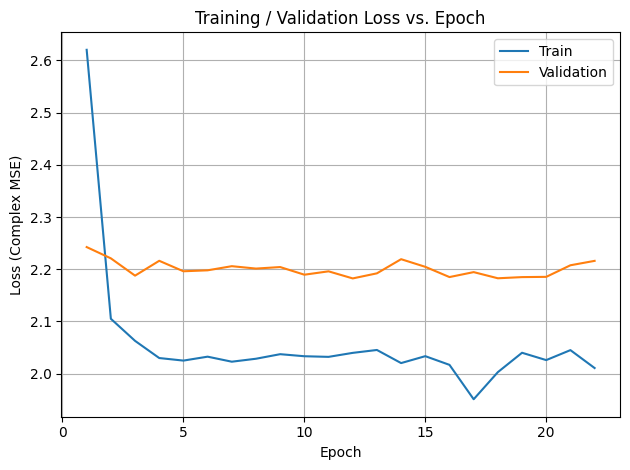

In [20]:

# 8) Plot loss curve
plot_loss_curve()


In [21]:
# 8a) Check saved model file
import os

if os.path.exists(weights_path):
    size_mb = os.path.getsize(weights_path) / (1024 * 1024)
    print(f"Model file found: {weights_path} ({size_mb:.2f} MB)")
else:
    print("Model weights file not found:", weights_path)


Model file found: /content/gnn_fedformer_best.pt (5.48 MB)
